In [1]:
import gymnasium as gym

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

**Description**

OpenAI Gym’s LunarLander-v3 environment has been used. The agent uses a Deep Q-Network (DQN) that learns to land the spacecraft smoothly. The neural network estimates Q-values for each action given the current state. The agent learns via experience replay and updates a target network periodically to stabilize learning

# Create a DQN Agent

In [8]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random
import imageio

from tqdm import trange, tqdm

In [3]:
# --- Define the Q-network ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.layers(x)


# --- Define Replay Buffer ---
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(states),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)


# --- DQN Agent ---
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=1e-3)
        self.replay_buffer = ReplayBuffer()
        self.batch_size = 64
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(action_dim)
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.q_net(state)).item()

    def update(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q_values = self.target_net(next_states).max(1)[0]
        expected_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        loss = nn.MSELoss()(q_values, expected_q_values.detach())
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## Training

In [5]:
# --- Main training loop ---
env = gym.make("LunarLander-v3")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQNAgent(state_dim, action_dim)

episodes = 500
rewards_per_episode = []

# Create the tqdm progress bar
progress_bar = tqdm(range(episodes), desc="Training DQN")

print("Training DQN...")
# for ep in progress_bar:
for ep in range(episodes):
    print(f"Training episode {ep}")
    state, _ = env.reset()
    total_reward = 0

    print("Iterating over 1000 iterations")
    # for t in tqdm(range(1000), desc="Iterating over 1000 iterations"):
    for t in range(1000):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward

        agent.update()
        if done:
            break

    agent.update_target()
    agent.decay_epsilon()
    rewards_per_episode.append(total_reward)

    # Update progress bar with episode stats
    progress_bar.set_postfix({
        "Reward": f"{total_reward:.2f}",
        "Epsilon": f"{agent.epsilon:.3f}"
    })

    # Optional: print every 50 episodes
    if ep % 50 == 0:
        print(f"Episode {ep}, Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.3f}")

env.close()

Training DQN:   0%|                                     | 0/500 [00:00<?, ?it/s]/tmp/ipykernel_56161/411135496.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  torch.FloatTensor(states),
Training DQN:   0%|       | 0/500 [00:00<?, ?it/s, Reward=-70.37, Epsilon=0.995]

Training DQN...
Training episode 0
Iterating over 1000 iterations
Episode 0, Reward: -70.37, Epsilon: 0.995
Training episode 1
Iterating over 1000 iterations


Training DQN:   0%|       | 0/500 [00:00<?, ?it/s, Reward=-98.75, Epsilon=0.990]

Training episode 2
Iterating over 1000 iterations


Training DQN:   0%|        | 0/500 [00:00<?, ?it/s, Reward=14.06, Epsilon=0.985]

...

Training DQN:   0%|         | 0/500 [14:38<?, ?it/s, Reward=2.10, Epsilon=0.082]

Training episode 498
Iterating over 1000 iterations


Training DQN:   0%|       | 0/500 [14:39<?, ?it/s, Reward=230.95, Epsilon=0.082]

Training episode 499
Iterating over 1000 iterations


Training DQN:   0%|       | 0/500 [14:41<?, ?it/s, Reward=261.54, Epsilon=0.082]

In [8]:
# Save the Q-network
torch.save(agent.q_net.state_dict(), "dqn_lunar_lander.pth")
print("Q-network saved as 'dqn_lunar_lander.pth")

Q-network saved as 'dqn_lunar_lander.pth


## Inference

In [4]:
def run_inference(model_path="dqn_lunar_lander.pth", episodes=5, render=True):
    # Create environment (render_mode='human' for visualization)
    env = gym.make("LunarLander-v3", render_mode='human' if render else None)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Initialize network and load weights
    q_net = QNetwork(state_dim, action_dim)
    q_net.load_state_dict(torch.load(model_path))
    q_net.eval()

    print(f"Loaded trained model from '{model_path}'")
    print(f"Running {episodes} inference episodes...\n")

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        t = 0

        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            with torch.no_grad():
                action = torch.argmax(q_net(state_tensor)).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            state = next_state
            t += 1

        print(f"Episode {ep + 1} finished in {t} steps | Total Reward: {total_reward:.2f}")

    env.close()
    print("\nInference complete.")


In [5]:
run_inference("dqn_lunar_lander.pth", episodes=5, render=True)

Loaded trained model from 'dqn_lunar_lander.pth'
Running 5 inference episodes...

Episode 1 finished in 206 steps | Total Reward: 262.96
Episode 2 finished in 249 steps | Total Reward: 248.91
Episode 3 finished in 218 steps | Total Reward: 271.44
Episode 4 finished in 301 steps | Total Reward: 275.85
Episode 5 finished in 233 steps | Total Reward: 233.17

Inference complete.


## Rendering video

In [9]:
# --- Load environment ---
env = gym.make("LunarLander-v3", render_mode="rgb_array")

# --- Prepare model (same dimensions as during training) ---
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

model = QNetwork(state_dim, action_dim)

# --- Load your trained model weights ---
# Replace the filename below with your actual saved file (e.g., "dqn_lander.pth")
model.load_state_dict(torch.load("dqn_lunar_lander.pth", map_location=torch.device("cpu")))
model.eval()

# --- Record video frames ---
frames = []
state, _ = env.reset(seed=42)
done = False

while not done:
    frame = env.render()               # Capture current frame
    frames.append(frame)               # Store frame for video

    # Select best action from trained policy
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    with torch.no_grad():
        action = torch.argmax(model(state_tensor)).item()

    # Step environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state = next_state

env.close()

# --- Save frames as MP4 ---
imageio.mimsave("dqn_lunarlander.mp4", frames, fps=30)
print("🎥 Video saved as dqn_lunarlander.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


🎥 Video saved as dqn_lunarlander.mp4


In [10]:
from IPython.display import Video
Video("dqn_lunarlander.mp4", embed=True)

# Demo (running the trained agent)

In [11]:
env = gym.make("LunarLander-v3", render_mode="human")
state, _ = env.reset()
done = False
while not done:
    action = agent.select_action(state)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
env.close()

# Improvement visualization (plotting rewards)

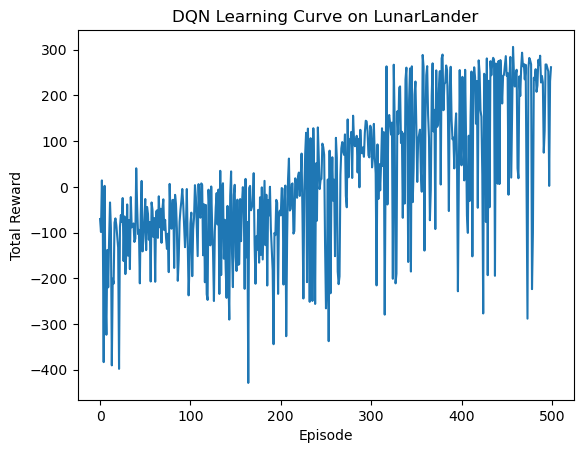

In [14]:
import matplotlib.pyplot as plt
plt.plot(rewards_per_episode)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Learning Curve on LunarLander")
plt.savefig("DQN_learningCurve_LunarLander.png")
plt.show()